Worksheet 3 - Modelling the Neuron

Name: Ishwor Chalise

Module: 6CS012 - Artificial Intelligence and Machine Learning

In [2]:

# Full file paths
file_0_1 = "C:\\Users\\asus\\Documents\\class\\3.2\\Machinelearning and ai\\mnist_0_and_1.csv"
file_3_5 = "C:\\Users\\asus\\Documents\\class\\3.2\\Machinelearning and ai\\mnist_3_and_5.csv"

print("0 vs 1 file:", file_0_1)
print("3 vs 5 file:", file_3_5)

0 vs 1 file: C:\Users\asus\Documents\class\3.2\Machinelearning and ai\mnist_0_and_1.csv
3 vs 5 file: C:\Users\asus\Documents\class\3.2\Machinelearning and ai\mnist_3_and_5.csv


## Imports

These are the libraries used in the worksheet.

In [3]:
# Basic libraries for the worksheet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 3.2 Task - 1: Implementation of MCP Neurons

**Question:** Design a MCP Neuron for "AND" Boolean Functions and "OR" Boolean Functions with two inputs.

In [5]:
# MCP neuron for AND gate
def MCP_Neurons_AND(X1, X2, T):
    """
    This function does AND operation using MCP neuron idea.
    """
    assert len(X1) == len(X2)

    # making a list to store sum of inputs
    summed_inputs = []
    for i in range(len(X1)):
        summed_inputs.append(X1[i] + X2[i])

    # storing final neuron state here
    state_neuron = []
    for value in summed_inputs:
        if value >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# MCP neuron for OR gate
def MCP_Neurons_OR(X1, X2, T):
    """
    This function does OR operation using MCP neuron idea.
    """
    assert len(X1) == len(X2)

    # making a list to store sum of inputs
    summed_inputs = []
    for i in range(len(X1)):
        summed_inputs.append(X1[i] + X2[i])

    # storing final neuron state here
    state_neuron = []
    for value in summed_inputs:
        if value >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# input values for testing
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]

# threshold for AND
T_and = 2
result_and = MCP_Neurons_AND(X1, X2, T_and)
print("AND gate output:", result_and)

# threshold for OR
T_or = 1
result_or = MCP_Neurons_OR(X1, X2, T_or)
print("OR gate output:", result_or)

AND gate output: [0, 0, 0, 1]
OR gate output: [0, 1, 1, 1]


### 3.2.1 Answer the Following Question

**Question - 1:** List out all the limitations of MCP - Neurons.

1. It uses fixed weights or fixed logic, so it does not learn from data.
2. It can only solve simple linearly separable problems.
3. It cannot solve XOR with a single MCP neuron.
4. It is a very simplified model and does not represent real biological neurons fully.
5. It gives only binary output like 0 or 1.
6. It does not update itself using errors or feedback.
7. It is not suitable for complex pattern recognition tasks.

**Question - 2:** Think if you can develop a logic to solve for XOR function using MCP Neuron. {Can you devise a if else rules.}

In [6]:
# My short answer for XOR using a single MCP neuron
answer_xor = "A single MCP neuron cannot solve XOR because XOR is not linearly separable."
print(answer_xor)

# But we can still show XOR truth table using simple if else rules
def xor_with_if_else(x1, x2):
    # XOR gives 1 when inputs are different
    if x1 == 0 and x2 == 0:
        return 0
    elif x1 == 0 and x2 == 1:
        return 1
    elif x1 == 1 and x2 == 0:
        return 1
    else:
        return 0


pairs = [(0, 0), (0, 1), (1, 0), (1, 1)]
for p in pairs:
    print(p, "->", xor_with_if_else(p[0], p[1]))

print("So, XOR can be written with if else rules, but not by a single basic MCP neuron.")

A single MCP neuron cannot solve XOR because XOR is not linearly separable.
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0
So, XOR can be written with if else rules, but not by a single basic MCP neuron.


## 4.3 Task 2: Perceptron Algorithm for 0 vs 1 Classification

**Question:** Load the Dataset: Start by loading the MNIST dataset containing digits 0 and 1.

In [8]:
# Load the 0 and 1 dataset from the current directory
file_0_1 = "mnist_0_and_1.csv"
df_0_1 = pd.read_csv(file_0_1)

# Separate features and labels
X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

# Check shape of data
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Answer the Following Question

**Question - 1:** What does the shape of X represent?

The shape of X shows the number of images and the number of features in each image.
Rows mean total samples and columns mean total pixel values for each sample.
For MNIST, each image has 784 features because 28 x 28 = 784.

**Question - 2:** What does the shape of y represent?



The shape of y shows how many labels are in the dataset.
It should have one label for every image in X.


**Question:** Visualize the Dataset.

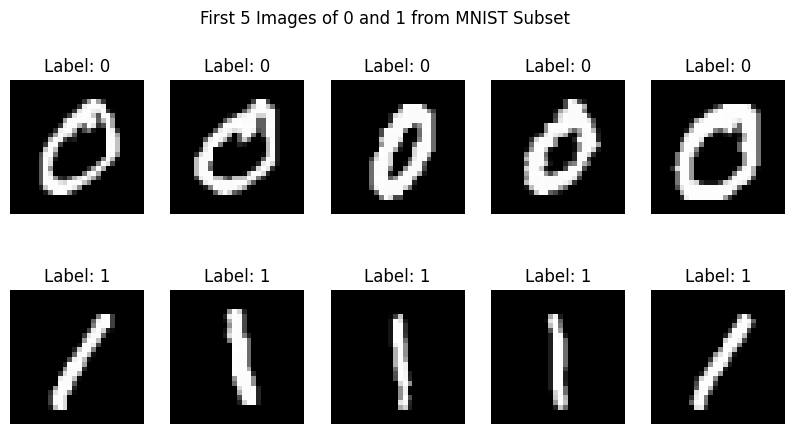

In [9]:
# Separate images based on label
images_0 = X[y == 0]
images_1 = X[y == 1]

# Show first 5 images of each class
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Not enough images to plot.")
else:
    for i in range(5):
        # top row for digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        # bottom row for digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

**Question:** Initialize Weights and Bias.

In [10]:
# Initialize weights and bias
# We keep all weights zero at the start
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

print("Weights shape:", weights.shape)
print("Initial bias:", bias)

Weights shape: (784,)
Initial bias: 0


### Answer the Following Question

**Question - 3:** What does the weights array represent in this context?

The weights array stores one weight for each pixel feature.
These weights tell the perceptron how important each pixel is for prediction.

**Question - 4:** Why are we initializing the weights to zero? What effect

---

could this have on the training process?



We initialize weights to zero because it is simple and easy to start with.
Then the perceptron changes the weights during training when it makes mistakes.
For this basic perceptron, zero initialization is okay, but the model may need some updates before it learns a good boundary.


**Question:** Implement a Decision Function or Activation Function.

In [11]:
# Decision function for perceptron
def decision_function(X, weights, bias):
    """
    Compute predicted labels.
    """
    # calculate weighted sum
    predictions = np.dot(X, weights) + bias

    # apply step function
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all


# quick test on first few examples
test_preds = decision_function(X[:5], weights, bias)
print("First 5 predictions:", test_preds)

First 5 predictions: [1 1 1 1 1]


**Question:** Implement the Perceptron Learning Algorithm.

In [12]:
# Training function for perceptron
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train perceptron on given data.
    """
    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            # weighted sum for one training example
            output = np.dot(X[i], weights) + bias

            # step function
            if output >= 0:
                prediction = 1
            else:
                prediction = 0

            # if prediction is right, count it
            if prediction == y[i]:
                correct = correct + 1
            else:
                # update rule when prediction is wrong
                weights = weights + learning_rate * (y[i] - prediction) * X[i]
                bias = bias + learning_rate * (y[i] - prediction)

        # accuracy for this epoch
        accuracy = correct / len(X)

        # print some progress so we can see training
        if epoch % 10 == 0 or epoch == epochs - 1:
            print("Epoch:", epoch, "Accuracy:", accuracy)

    return weights, bias, accuracy

### Answer the Following Question

**Question - 5:** What is the purpose of the `output = np.dot(X[i], weights) + bias` line?

This line calculates the weighted sum for one input image.
The perceptron uses this value to decide whether the prediction should be 0 or 1.

**Question - 6:** What happens when the prediction is wrong? How are the weights and bias updated?



When the prediction is wrong, the perceptron updates the weights and bias.
It uses this rule: weights = weights + learning_rate * (true label - prediction) * input
And bias = bias + learning_rate * (true label - prediction)
This helps move the decision boundary in a better direction.


**Question - 7:** Why is the final accuracy important, and what do you expect it to be?

Final accuracy is important because it shows how well the model learned to classify the digits.
For 0 and 1, I expect the accuracy to be high because these two digits are usually easier to separate.

**Question:** Putting it all together - Train the perceptron algorithm on whole dataset.

In [13]:
# Train the perceptron on the full 0 vs 1 dataset
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)
print("The Final Accuracy is:", accuracy)

Epoch: 0 Accuracy: 0.9966837741808132
Epoch: 10 Accuracy: 0.9995262534544019
Epoch: 20 Accuracy: 1.0
Epoch: 30 Accuracy: 1.0
Epoch: 40 Accuracy: 1.0
Epoch: 50 Accuracy: 1.0
Epoch: 60 Accuracy: 1.0
Epoch: 70 Accuracy: 1.0
Epoch: 80 Accuracy: 1.0
Epoch: 90 Accuracy: 1.0
Epoch: 99 Accuracy: 1.0
The Final Accuracy is: 1.0


**Question:** Visualizing the Misclassified Image.

In [14]:
# Get predictions for all samples
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Final accuracy again
final_accuracy = np.mean(y_pred == y)
print("Final Accuracy:", final_accuracy)

# Find wrong predictions
misclassified_idx = np.where(y_pred != y)[0]
print("Total misclassified images:", len(misclassified_idx))

# Show up to 10 wrong images
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title("Pred: " + str(y_pred[idx]) + ", True: " + str(y[idx]))
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0
Total misclassified images: 0
All images were correctly classified!


### Answer the Following Question

**Question - 8:** What does `misclassified_idx` store, and how is it used in this code?

misclassified_idx stores the index positions of the samples that were predicted wrongly.
These index values are used to find and display the wrong images from the dataset.

**Question - 9:** How do you interpret the result if the output is "All images were correctly classified!"?



It means the model predicted every image correctly on that dataset.
So there were no misclassified samples left after training.


## 4.4 Task 3: Perceptron Algorithm for 3 vs 5 Classification

**Question:** Implement each step as above for the dataset `mnist_3_and_5.csv`, visualize the final misclassified images, and provide your conclusion.

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


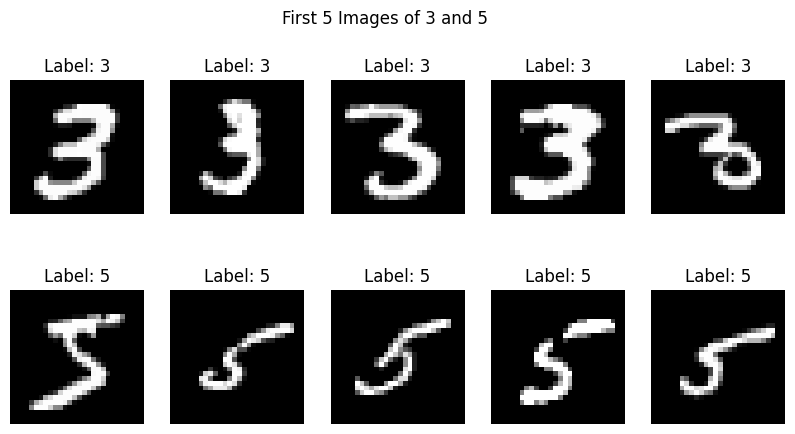

Epoch: 0 Accuracy: 0.9157241882524626
Epoch: 10 Accuracy: 0.9598686610726013
Epoch: 20 Accuracy: 0.9700839109813937
Epoch: 30 Accuracy: 0.9668004377964247
Epoch: 40 Accuracy: 0.9759211966435607
Epoch: 50 Accuracy: 0.9762860269974462
Epoch: 60 Accuracy: 0.9751915359357899
Epoch: 70 Accuracy: 0.9810288215979569
Epoch: 80 Accuracy: 0.9792046698285297
Epoch: 90 Accuracy: 0.9824881430134987
Epoch: 99 Accuracy: 0.9857716161984678
Final training accuracy for 3 vs 5: 0.9857716161984678
Final Accuracy for 3 vs 5: 0.986866107260124
Total misclassified images: 36


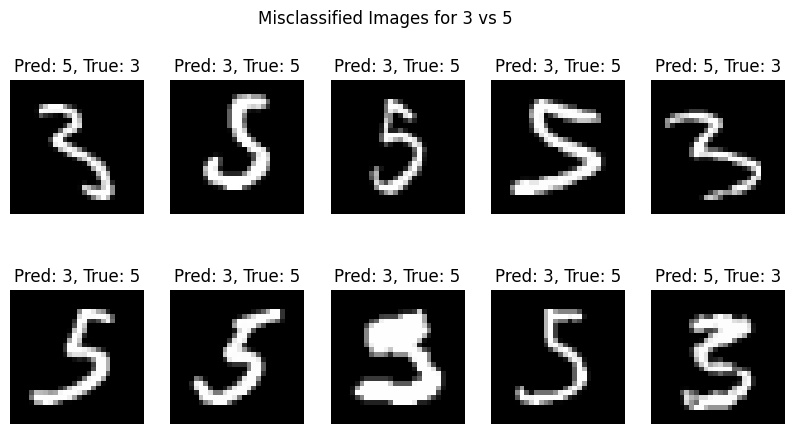

In [16]:
# Load 3 vs 5 dataset from the local directory
file_3_5 = "mnist_3_and_5.csv"
df_3_5 = pd.read_csv(file_3_5)

# Separate features and labels
X_35 = df_3_5.drop(columns=["label"]).values
y_35 = df_3_5["label"].values

print("Feature matrix shape:", X_35.shape)
print("Label vector shape:", y_35.shape)

# Visualize some examples
images_3 = X_35[y_35 == 3]
images_5 = X_35[y_35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Not enough images to plot.")
else:
    for i in range(5):
        # top row for digit 3
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        # bottom row for digit 5
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 3 and 5")
    plt.show()

# Change labels to binary because perceptron gives 0 or 1
# 3 becomes 0 and 5 becomes 1
y_35_binary = np.where(y_35 == 3, 0, 1)

# Initialize weights and bias
weights_35 = np.zeros(X_35.shape[1])
bias_35 = 0

# Train perceptron
weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35,
    y_35_binary,
    weights_35,
    bias_35,
    learning_rate=0.1,
    epochs=100
)

print("Final training accuracy for 3 vs 5:", accuracy_35)

# Predict on the whole dataset
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35 = np.where(predictions_35 >= 0, 1, 0)

# Calculate final accuracy
final_accuracy_35 = np.mean(y_pred_35 == y_35_binary)
print("Final Accuracy for 3 vs 5:", final_accuracy_35)

# Find wrong predictions
misclassified_idx_35 = np.where(y_pred_35 != y_35_binary)[0]
print("Total misclassified images:", len(misclassified_idx_35))

# Show misclassified images
if len(misclassified_idx_35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx_35[:10]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")

        # convert binary prediction back to actual digit for display
        pred_digit = 3 if y_pred_35[idx] == 0 else 5
        true_digit = y_35[idx]

        ax.set_title("Pred: " + str(pred_digit) + ", True: " + str(true_digit))
        ax.axis("off")

    plt.suptitle("Misclassified Images for 3 vs 5")
    plt.show()
else:
    print("All images were correctly classified!")

**Conclusion:** Provide your conclusion.

Conclusion:
The perceptron worked better on 0 vs 1 than on 3 vs 5.
This is because 3 and 5 look more similar, so classification is harder.
The misclassified images show the limits of a simple perceptron when classes are harder to separate.